In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

BASE = r"C:\Users\Admin\Desktop\AI-Business-Risk-Intelligence"
MODEL_PATH = os.path.join(BASE, "models_saved")

# Load data
telco = pd.read_csv(os.path.join(BASE, "data", "processed", "telco_with_predictions.csv"))

# Load models
m30 = joblib.load(os.path.join(MODEL_PATH, "churn_30day.pkl"))
m60 = joblib.load(os.path.join(MODEL_PATH, "churn_60day.pkl"))
m90 = joblib.load(os.path.join(MODEL_PATH, "churn_90day.pkl"))
scaler = joblib.load(os.path.join(MODEL_PATH, "scaler.pkl"))

print("✅ All models and data loaded!")
print(f"📊 Dataset shape: {telco.shape}")

✅ All models and data loaded!
📊 Dataset shape: (7043, 24)


In [2]:
from sklearn.preprocessing import LabelEncoder

def encode_features(df):
    df = df.copy()
    le = LabelEncoder()
    # Drop prediction columns first
    drop_cols = ['churn_prob_30day','churn_prob_60day',
                 'churn_prob_90day','churn_risk','risk_category']
    for col in drop_cols:
        if col in df.columns:
            df.drop(col, axis=1, inplace=True)
    
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))
    return df

df_encoded = encode_features(telco.copy())
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=X.columns
)

print("✅ Data prepared for SHAP!")
print(f"Features: {X.columns.tolist()}")

✅ Data prepared for SHAP!
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [3]:
print("⚙️ Calculating SHAP values... (takes 1-2 mins)")

# Create SHAP explainer
explainer = shap.TreeExplainer(m30)
shap_values = explainer.shap_values(X_scaled)

print("✅ SHAP values calculated!")
print(f"Shape of SHAP values: {shap_values.shape}")

⚙️ Calculating SHAP values... (takes 1-2 mins)
✅ SHAP values calculated!
Shape of SHAP values: (7043, 19)


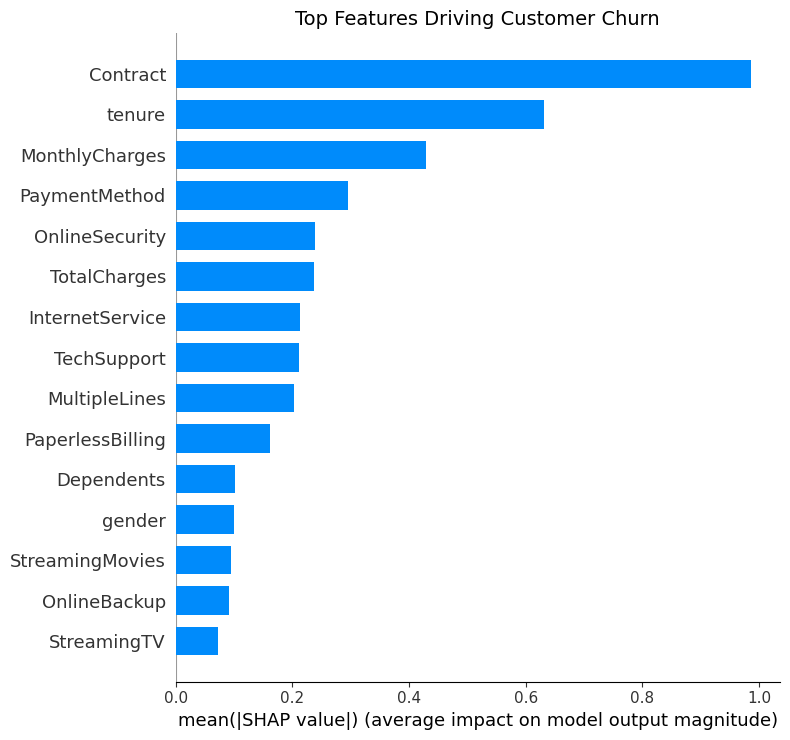

✅ SHAP Summary Plot saved!


In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_scaled,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top Features Driving Customer Churn", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "docs", "shap_summary.png"), dpi=150)
plt.show()
print("✅ SHAP Summary Plot saved!")

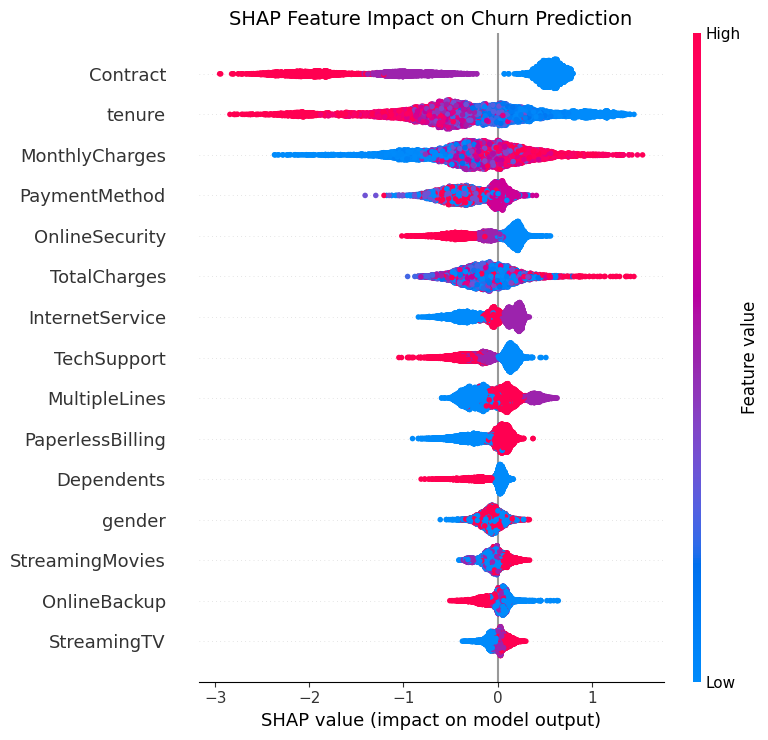

✅ Beeswarm plot saved!


In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_scaled,
    max_display=15,
    show=False
)
plt.title("SHAP Feature Impact on Churn Prediction", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "docs", "shap_beeswarm.png"), dpi=150)
plt.show()
print("✅ Beeswarm plot saved!")

In [6]:
def explain_customer(customer_idx):
    """Explain WHY a specific customer is at risk"""
    
    customer = X_scaled.iloc[[customer_idx]]
    customer_shap = shap_values[customer_idx]
    
    # Get top 5 reasons
    feature_impact = pd.DataFrame({
        'Feature': X_scaled.columns,
        'SHAP Value': customer_shap,
        'Impact': abs(customer_shap)
    }).sort_values('Impact', ascending=False).head(5)
    
    churn_prob = m30.predict_proba(customer)[0][1] * 100
    
    print(f"👤 CUSTOMER {customer_idx} — RISK EXPLANATION")
    print("=" * 55)
    print(f"🔮 Churn Probability (30 days): {churn_prob:.1f}%")
    
    if churn_prob >= 75:
        print("⚠️  Risk Level: 🔴 CRITICAL — Immediate action needed!")
    elif churn_prob >= 50:
        print("⚠️  Risk Level: 🟠 HIGH — Action required soon!")
    elif churn_prob >= 25:
        print("⚠️  Risk Level: 🟡 MEDIUM — Monitor closely!")
    else:
        print("✅  Risk Level: 🟢 LOW — Customer is safe!")
    
    print(f"\n📋 TOP 5 REASONS WHY:")
    print("-" * 55)
    for i, row in feature_impact.iterrows():
        direction = "⬆️ increases" if row['SHAP Value'] > 0 else "⬇️ decreases"
        print(f"  • {row['Feature']}: {direction} churn risk")
    
    return churn_prob

# Explain highest risk customer
high_risk_idx = telco['churn_prob_30day'].idxmax()
explain_customer(high_risk_idx)

👤 CUSTOMER 4453 — RISK EXPLANATION
🔮 Churn Probability (30 days): 98.7%
⚠️  Risk Level: 🔴 CRITICAL — Immediate action needed!

📋 TOP 5 REASONS WHY:
-------------------------------------------------------
  • MonthlyCharges: ⬆️ increases churn risk
  • Contract: ⬆️ increases churn risk
  • tenure: ⬆️ increases churn risk
  • MultipleLines: ⬆️ increases churn risk
  • InternetService: ⬆️ increases churn risk


np.float32(98.69596)

In [7]:
print("TOP 5 HIGH RISK CUSTOMERS — AI EXPLANATIONS")
print("=" * 55)

top5_idx = telco.nlargest(5, 'churn_prob_30day').index.tolist()

for idx in top5_idx:
    print()
    explain_customer(idx)
    print()

TOP 5 HIGH RISK CUSTOMERS — AI EXPLANATIONS

👤 CUSTOMER 4453 — RISK EXPLANATION
🔮 Churn Probability (30 days): 98.7%
⚠️  Risk Level: 🔴 CRITICAL — Immediate action needed!

📋 TOP 5 REASONS WHY:
-------------------------------------------------------
  • MonthlyCharges: ⬆️ increases churn risk
  • Contract: ⬆️ increases churn risk
  • tenure: ⬆️ increases churn risk
  • MultipleLines: ⬆️ increases churn risk
  • InternetService: ⬆️ increases churn risk


👤 CUSTOMER 4517 — RISK EXPLANATION
🔮 Churn Probability (30 days): 98.6%
⚠️  Risk Level: 🔴 CRITICAL — Immediate action needed!

📋 TOP 5 REASONS WHY:
-------------------------------------------------------
  • MonthlyCharges: ⬆️ increases churn risk
  • Contract: ⬆️ increases churn risk
  • TotalCharges: ⬆️ increases churn risk
  • tenure: ⬆️ increases churn risk
  • InternetService: ⬆️ increases churn risk


👤 CUSTOMER 3349 — RISK EXPLANATION
🔮 Churn Probability (30 days): 98.3%
⚠️  Risk Level: 🔴 CRITICAL — Immediate action needed!

📋 TOP

In [8]:
def generate_risk_report(customer_idx):
    """Auto generate English risk report"""
    
    customer = X_scaled.iloc[[customer_idx]]
    customer_shap = shap_values[customer_idx]
    
    feature_impact = pd.DataFrame({
        'Feature': X_scaled.columns,
        'SHAP Value': customer_shap,
        'Impact': abs(customer_shap)
    }).sort_values('Impact', ascending=False).head(3)
    
    churn_30 = m30.predict_proba(customer)[0][1] * 100
    churn_60 = m60.predict_proba(customer)[0][1] * 100
    churn_90 = m90.predict_proba(customer)[0][1] * 100
    
    top_reasons = feature_impact['Feature'].tolist()
    
    report = f"""
╔══════════════════════════════════════════════════╗
║         AI CUSTOMER RISK REPORT                  ║
╠══════════════════════════════════════════════════╣
║  Customer ID   : {customer_idx}
║  
║  CHURN PROBABILITY:
║  → Next 30 Days : {churn_30:.1f}%
║  → Next 60 Days : {churn_60:.1f}%
║  → Next 90 Days : {churn_90:.1f}%
║  
║  TOP RISK FACTORS:
║  1. {top_reasons[0]}
║  2. {top_reasons[1]}
║  3. {top_reasons[2]}
║  
║  AI RECOMMENDATION:"""
    
    if churn_30 >= 75:
        report += """
║  🔴 CRITICAL: Contact customer immediately!
║  → Offer special retention discount
║  → Assign dedicated support manager
║  → Resolve any pending complaints"""
    elif churn_30 >= 50:
        report += """
║  🟠 HIGH RISK: Act within 7 days
║  → Send personalized email offer
║  → Offer loyalty rewards"""
    elif churn_30 >= 25:
        report += """
║  🟡 MEDIUM RISK: Monitor weekly
║  → Send engagement newsletter
║  → Offer minor discount"""
    else:
        report += """
║  🟢 LOW RISK: Customer is happy!
║  → Maintain current service
║  → Consider upsell opportunity"""
    
    report += """
╚══════════════════════════════════════════════════╝"""
    
    return report

# Generate report for highest risk customer
print(generate_risk_report(high_risk_idx))


╔══════════════════════════════════════════════════╗
║         AI CUSTOMER RISK REPORT                  ║
╠══════════════════════════════════════════════════╣
║  Customer ID   : 4453
║  
║  CHURN PROBABILITY:
║  → Next 30 Days : 98.7%
║  → Next 60 Days : 96.1%
║  → Next 90 Days : 91.4%
║  
║  TOP RISK FACTORS:
║  1. MonthlyCharges
║  2. Contract
║  3. tenure
║  
║  AI RECOMMENDATION:
║  🔴 CRITICAL: Contact customer immediately!
║  → Offer special retention discount
║  → Assign dedicated support manager
║  → Resolve any pending complaints
╚══════════════════════════════════════════════════╝


In [9]:
# Save SHAP values
shap_df = pd.DataFrame(shap_values, columns=X_scaled.columns)
shap_df.to_csv(
    os.path.join(BASE, "data", "processed", "shap_values.csv"),
    index=False
)

print("✅ SHAP values saved!")
print("\n" + "="*50)
print("🎉 WEEK 5 COMPLETE!")
print("="*50)
print("✅ SHAP Explainer Built")
print("✅ Summary Plot Created")
print("✅ Beeswarm Plot Created")
print("✅ Single Customer Explanation Working")
print("✅ Auto English Risk Report Generated")
print("✅ SHAP values saved to processed folder")
print("\n🚀 Ready for Week 6 — What-If Simulator!")

✅ SHAP values saved!

🎉 WEEK 5 COMPLETE!
✅ SHAP Explainer Built
✅ Summary Plot Created
✅ Beeswarm Plot Created
✅ Single Customer Explanation Working
✅ Auto English Risk Report Generated
✅ SHAP values saved to processed folder

🚀 Ready for Week 6 — What-If Simulator!
